# CUSTOMER CHURN PREDICTION PROJECT

# 1. Project Introduction

 Customer Churn Prediction is a Machine Learning project used to predict whether a customer is likely to leave a company's service.

 Customer churn is an impotant business problem because losing existing customers can negatively affect company revenue and growth

 In this project, we will analyze customer information such as tenure, contract type, monthly charges, payment method, and mervices used by customers.

 We will clean and explore the dataset, perform data visualization, prepare the data for Machine Learning, train a Logistic Regression model, and 
 evalute its performance.

 This main objective of this project is to identify customers who are more likely to churn and help businesses take suitable actions to improve
 customer retention.

# 2. Import Required Libraries

In [3]:
# Pandas is used for data manipulation and analysis 
import pandas as pd

# Numpy is used for numerical operations
import numpy as np

# Matplotlib is used for daata visualization
import matplotlib.pyplot as plt

# Seaborn is used for attractive statistical visualizations
import seaborn as sns

# Used to split the dataset into training and testing data
from sklearn.model_selection import train_test_split

# Used to convert categorical values into numerical values
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning classification algorithm
from sklearn.linear_model import LogisticRegression

# Used to evaluate the Machine Learning model
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

# Display plots inside Jupyter Notebook
%matplotlib inline

# 3. Load the Dataset

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the dataest
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# 4. Display First 5 Rows

In [6]:
# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 5. Display Dataset Shape 

In [7]:
# Display the number of rows and columns
df.shape

(7043, 21)

# 6. Check Column Names

In [8]:
# Display all Column names in dataset
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

# 7. Dataset Information

In [9]:
# Display information about columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# 8. Statistical Summary

In [10]:
# Display statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 9. Check Missing Values

In [11]:
# Count missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# 10. Check Duplicate Rows

In [12]:
# Count duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

# DATA CLEANING

# 11. Check TotalCharges Data Type

In [13]:
# Check the data type of TotalCharges
df["TotalCharges"].dtype

dtype('O')

# 12. Convert TotalCharges into Numeric

In [15]:
# Convert TotalCharges into numeric format
# Invalid values will be converted into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check data type 
df["TotalCharges"].dtype

dtype('float64')

# 13. Check Missing Values Again

In [16]:
# Count missing va;ues in each column
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

# 14. Remove Missing Values

In [17]:
# Remove rows containing missing values
df.dropna(inplace=True)

# Check the new shape of the dataset
df.shape

(7032, 21)

# 15. Check Dataset After Cleaning

In [18]:
# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EXPLORATORY DATA ANALYSIS

# 16. Churn Count

In [19]:
# Check the number of customers in each churn category
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

# 17. Churn Percentage

In [20]:
# Calculate the percentage of customers in each churn category
churn_percentage = df["Churn"].value_counts(normalize=True)*100

churn_percentage

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

# 18. Customer Churn Distribution

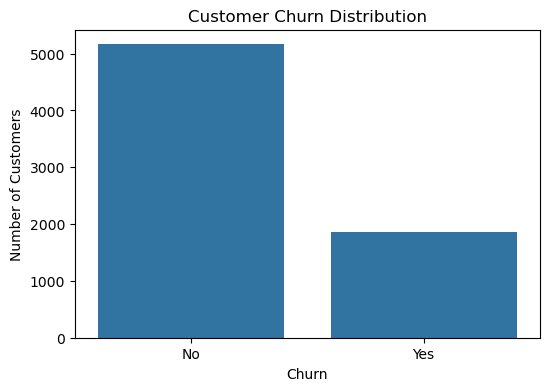

In [21]:
# Count customers based on their churn status

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

# 19. Churn by Gender

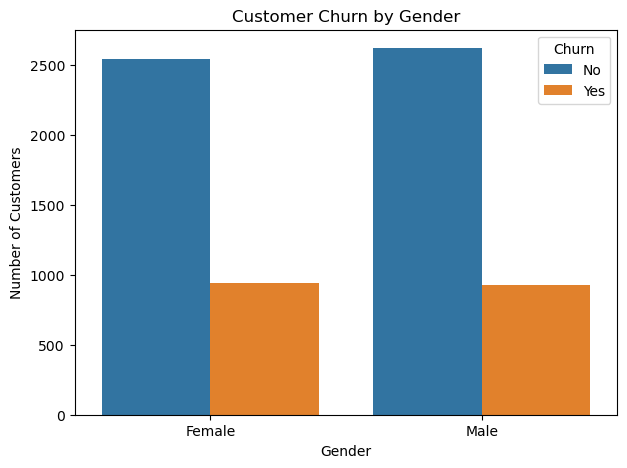

In [23]:
# Create a count plot to compare customer churn between male and female customers
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="gender", hue="Churn")

# Add chart title and axis labels
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

# 20. Churn by Contract Type

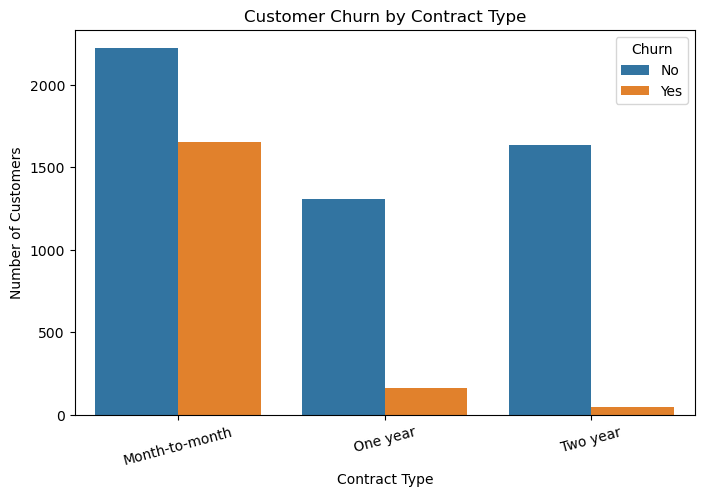

In [24]:
# Create a count plot to analyze churn based on different types of customer contracts
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

# Add chart title and axis labels
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Rotate x-axis labels for better readability
plt.xticks(rotation=15)

# Display the chart
plt.show()

# 21. Churn by Tenure

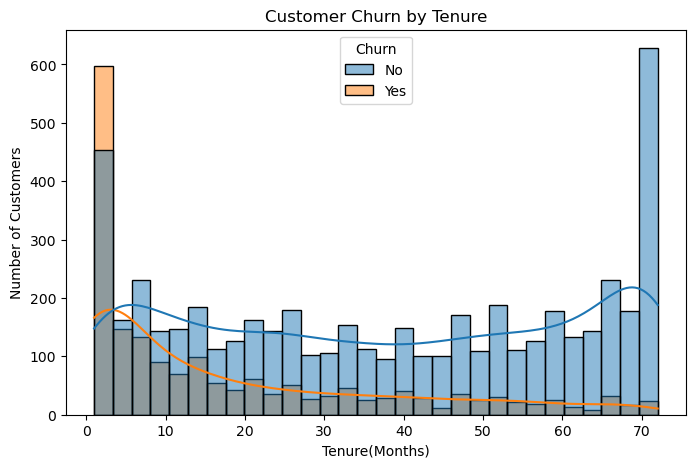

In [25]:
# Compare customer tenure for customers who churned and customers who stayed
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)

# Add chart title and axis labels
plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure(Months)")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

# 22. Monthly Charges Distribution

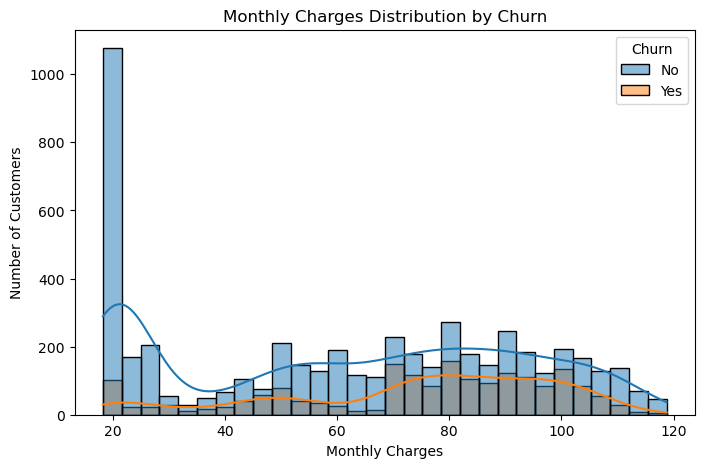

In [26]:
# Analyze the distribution of monthly charges for churnedand non-churned customers
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True)

# Add chart title and axis labels
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

# 23. Churn by Payment Method

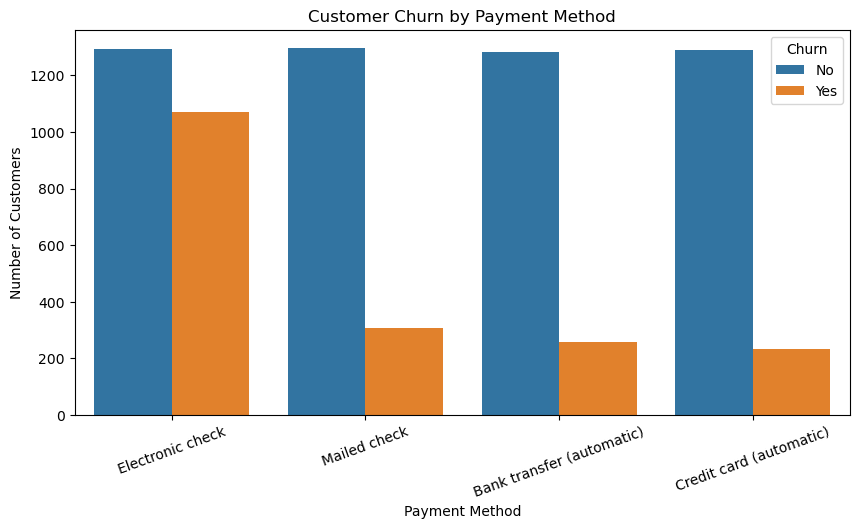

In [28]:
# Compare customer churn across different payment methods
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

# Add chart title and axis labels
plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

# Rotate labels for better readability
plt.xticks(rotation=20)

# Display the chart
plt.show()

# 24. Churn by Internet Service

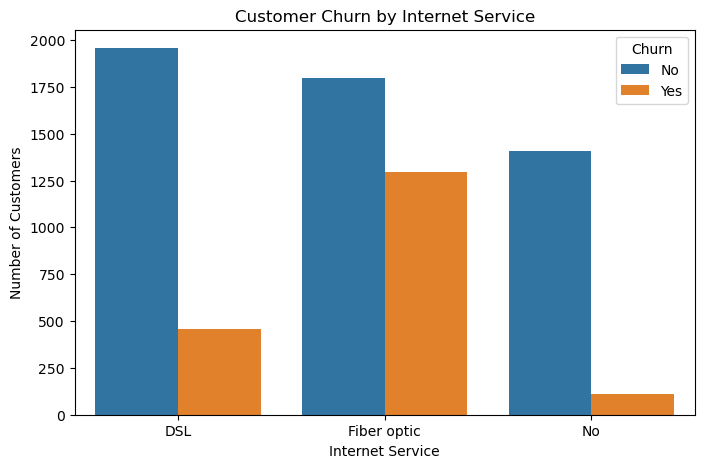

In [29]:
# Analyze customer churn based on the type of internet service used customers
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

# Add chart title and axis labels
plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

# DATA PREPROCESSING

# 25 Check Categorical Columns

In [30]:
# Display columns having categorical/text data
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

# 26. Convert Categorical Data into Numerical Data

In [31]:
# Convert a LabelEncoder object
label_encoder = LabelEncoder()

# Convert categorical columns into numerical values
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Display the first five rows after encoding
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5365,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3953,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5524,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6500,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


# 27. Check Dataset After Encoding

In [32]:
# Display information about the dataset after converting categorical values into numbers
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   int64  
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   int64  
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   int64  
 16  PaperlessBilling  7032 non-null   int64  
 17  

# 28. Separat Features and Target

In [33]:
# x contains the input features
# y contains the target variable

x = df.drop("Churn", axis=1)
y = df["Churn"]

# Display the shape of features and target
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (7032, 20)
Target shape: (7032,)


# 29. Split Data into Training and Testing Sets

In [35]:
# Split the dataset into training and testing data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of training and testing data
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (5625, 20)
Testing data: (1407, 20)


# 30 Feature Scaling

In [36]:
# Create a StandardScaler object 
scaler = StandardScaler()

# Fit the scaler on training data and transform it
x_train_scaled = scaler.fit_transform(x_train)

# Transform the testing data using the same scaler
x_test_scaled = scaler.transform(x_test)

# Display the shape of scaled training and testing data
print("Scaled Training Data:", x_train_scaled.shape)
print("scaled Testing Data:", x_test_scaled.shape)

Scaled Training Data: (5625, 20)
scaled Testing Data: (1407, 20)


#  31. Train Logistic Regression Model

In [37]:
# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(x_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


# 32. Make Predictions

In [38]:
# Predict churn for the testing data 
y_pred = model.predict(x_test_scaled)

# Display the first 10 predictions
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

# MODEL ACCURACY

# 33. Model Accuracy

In [39]:
# Calculate the accuracy of the model 
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print("Model Accuracy:", accuracy)
print("Acuuracy Percentage:", accuracy*100,"%")

Model Accuracy: 0.7938877043354655
Acuuracy Percentage: 79.38877043354655 %


# 34. Confusion Matrix

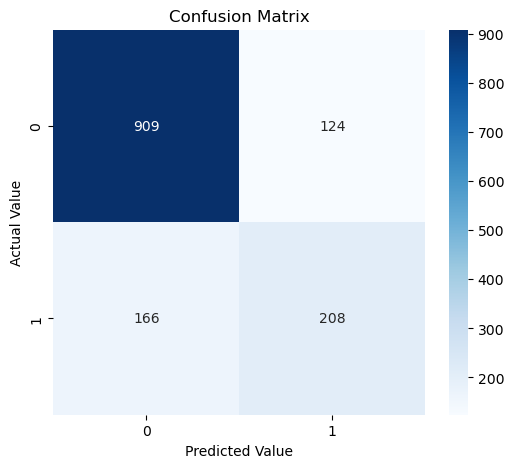

In [40]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for better visualization
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Add chart title and axis labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")

# Display the chart
plt.show()

# 35. Classification Report

In [41]:
# Display precision, recall and F1-score
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



# 36. Actual vs Predicted Churn

In [42]:
# Create a DataFrame to compare actual and predicted values
comparison = pd.DataFrame({"Actual Churn": y_test.values, "Predicted Churn": y_pred})

# Display the first 10 results
comparison.head(10)

,Actual Churn,Predicted Churn
0,0,0
1,0,1
2,0,0
3,1,0
4,0,0
5,1,0
6,0,0
7,0,0
8,1,1
9,0,0


# 37. Prediction Distribution

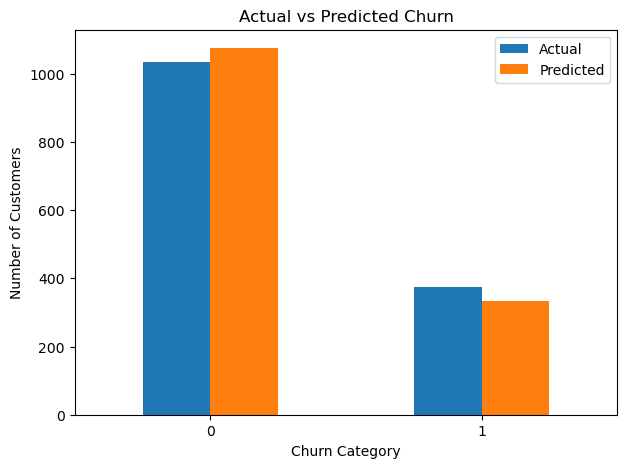

In [45]:
# Count actual and predicted churn values
actual_counts = pd.Series(y_test).value_counts().sort_index()

predicted_counts = pd.Series(y_pred).value_counts().sort_index()

# Create a comparison DataFrame
prediction_comparison = pd.DataFrame({"Actual": actual_counts, "Predicted": predicted_counts})

# plot the comparison
prediction_comparison.plot(kind="bar", figsize=(7,5))

# Add chart title and labels
plt.title("Actual vs Predicted Churn")
plt.xlabel("Churn Category")
plt.ylabel("Number of Customers")

# Rotate x_axis labels
plt.xticks(rotation=0)

# Display the chart
plt.show()

# 38. Feature Importance

In [48]:
# Get the importance of each feature from the Logistic Regression model using its coefficients
feature_importance = pd.DataFrame({"Feature": x.columns, "Importance": model.coef_[0]})

# Calculate absolute importance values
feature_importance["Absolute Importance"] = (feature_importance["Importance"].abs())

# Sort features by their importance
feature_importance = feature_importance.sort_values(by="Absolute Importance", ascending=False)

# Display the most important features
feature_importance.head(10)

,Feature,Importance,Absolute Importance
5,tenure,-1.328597,1.328597
18,MonthlyCharges,0.695969,0.695969
15,Contract,-0.625896,0.625896
19,TotalCharges,0.606337,0.606337
6,PhoneService,-0.301941,0.301941
9,OnlineSecurity,-0.250390,0.250390
12,TechSupport,-0.235382,0.235382
8,InternetService,0.170467,0.170467
16,PaperlessBilling,0.155956,0.155956
10,OnlineBackup,-0.140011,0.140011


# 39. Feature Importance Visualization

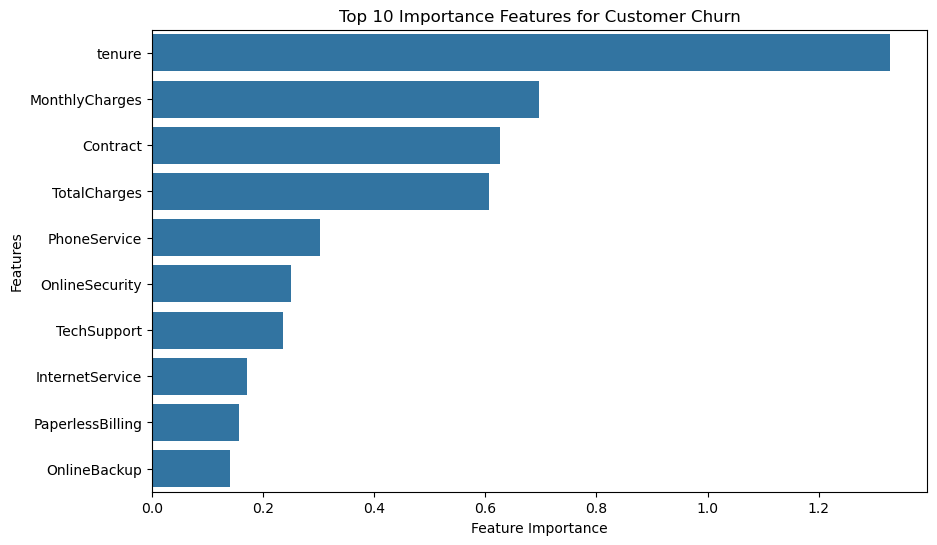

In [49]:
# Select top 10 important features
top_features = feature_importance.head(10)

# Create the bar chart
plt.figure(figsize=(10,6))

sns.barplot(data=top_features, x="Absolute Importance", y="Feature")

# Add chart title and axis labels
plt.title("Top 10 Importance Features for Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

# Display the chart
plt.show()

# 40. Project Conclusion

 In this Customer Churn Prediction project, we cleaned and analyzed customer data, performed Exploratory Data Analysis (EDA), and used a Machine Learning model tp predict customer churn.

 The Feature Importance chart helped us identify which features are most important for predicting customer churn. These insights can help businesses understand customer behavior and take effective steps to retain customers.

 Overall, this project demonstrates how Data Science and Machine Learning can be used to analyze customer behavior and help businesses reduce customer churn.